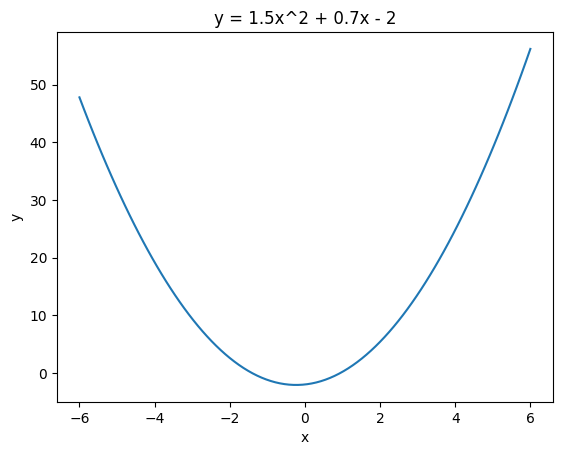

In [40]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)  # For reproducibility


# Set y = 1.5x^2 + 0.7x - 2
def F(x):
    return 1.5 * x**2 + 0.7 * x - 2


# Generate 100 uniformly spaced x values from -6 to 6
x = np.linspace(-6, 6, 100)

# Calculate corresponding y values using the function f
y = F(x)

# Plot the function
plt.plot(x, y)
plt.title("y = 1.5x^2 + 0.7x - 2")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

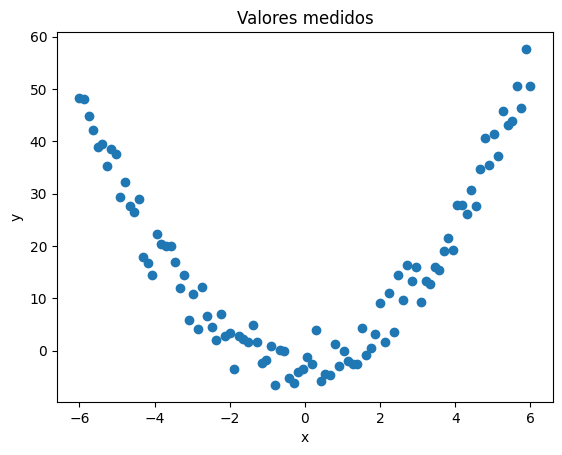

In [41]:
# Add noise to the y values
noise_amp = 0.1 * np.max(np.abs(y))
noise = np.random.uniform(-noise_amp, noise_amp, size=y.shape)
y_measured = y + noise

# Plot the noisy measurements
plt.scatter(x, y_measured)
plt.title("Valores medidos")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

A equação de regressão é $y = \theta_2x^2 + \theta_1x + \theta_0$.

A matriz de regressores é

$A =$
\begin{bmatrix}
x_1^2 & x_1 & 1 \\
x_2^2 & x_2 & 1 \\
\vdots & \vdots & \vdots \\
x_N^2 & x_N & 1
\end{bmatrix}

In [42]:
# Construct the design matrix for quadratic fitting
F_0 = np.vstack([x**2, x, np.ones(len(x))]).T

# Perform least squares fitting to find coefficients
theta, _, _, _ = np.linalg.lstsq(F_0, y_measured)

# Display the fitted coefficients
print("Coeficientes estimados:")
for i in range(len(theta)):
    print(f"θ_{i} = {theta[i]:.2f}")

Coeficientes estimados:
θ_0 = 1.52
θ_1 = 0.47
θ_2 = -2.59


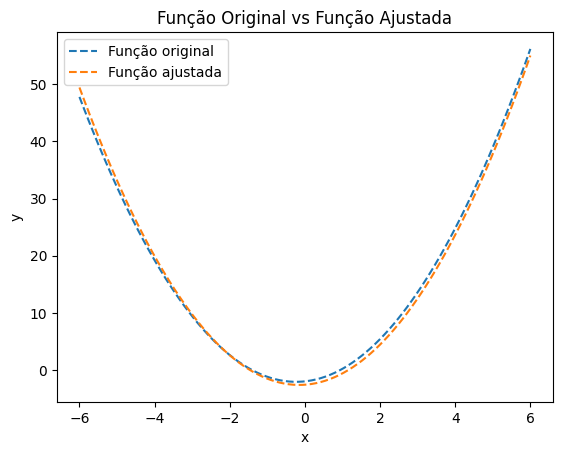

In [ ]:
# Define the fitted function
def f_fit(x, theta=theta):
    return theta[0] * x**2 + theta[1] * x + theta[2]


y_fit = f_fit(x, theta)

# Plot the original function and the fitted function
plt.plot(x, y, label="Referência", linestyle="--")
plt.plot(x, y_fit, label="Função ajustada", linestyle="--")
plt.title("Referência vs Função Ajustada")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [44]:
# Compute and display maximum, average and standard deviation of the error
error = y - y_fit
print(f"Erro máximo: {np.max(np.abs(error)):.2f}")
print(f"Erro médio: {np.mean(np.abs(error)):.2f}")
print(f"Desvio padrão do erro: {np.std(error):.2f}")

Erro máximo: 1.65
Erro médio: 0.82
Desvio padrão do erro: 0.86


In [45]:
# Repeat for N = 1000
x = np.linspace(-6, 6, 1000)
y = F(x)
noise_amp = 0.1 * np.max(np.abs(y))
noise = np.random.uniform(-noise_amp, noise_amp, size=y.shape)
y_measured = y + noise
F_0 = np.vstack([x**2, x, np.ones(len(x))]).T
theta, _, _, _ = np.linalg.lstsq(F_0, y_measured)
print("Coeficientes estimados para N=1000:")
for i in range(len(theta)):
    print(f"θ_{i} = {theta[i]:.2f}")

Coeficientes estimados para N=1000:
θ_0 = 1.51
θ_1 = 0.68
θ_2 = -2.12


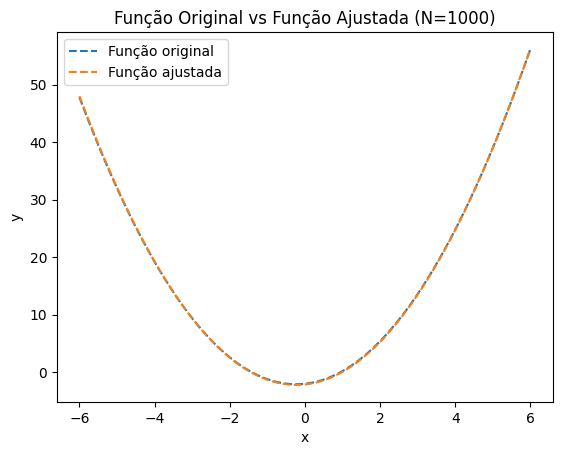

Erro máximo (N=1000): 0.23
Erro médio (N=1000): 0.09
Desvio padrão do erro (N=1000): 0.10


In [46]:
# Compute the fitted values
y_fit = f_fit(x, theta)

# Plot the original function and the fitted function for N=1000
plt.plot(x, y, label="Função original", linestyle="--")
plt.plot(x, y_fit, label="Função ajustada", linestyle="--")
plt.title("Função Original vs Função Ajustada (N=1000)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# Compute and display maximum, average and standard deviation of the error
error = y - y_fit
print(f"Erro máximo (N=1000): {np.max(np.abs(error)):.2f}")
print(f"Erro médio (N=1000): {np.mean(np.abs(error)):.2f}")
print(f"Desvio padrão do erro (N=1000): {np.std(error):.2f}")

Coeficientes estimados com ruído em x (N=1000):
θ_0 = 1.25
θ_1 = 0.66
θ_2 = 0.58


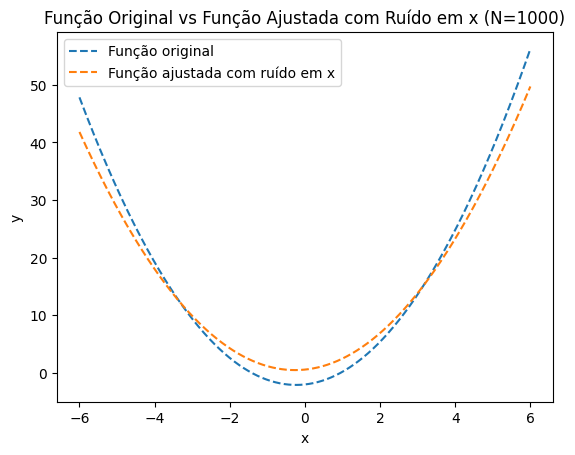

Erro máximo com ruído em x (N=1000): 6.51
Erro médio com ruído em x (N=1000): 2.23
Desvio padrão do erro com ruído em x (N=1000): 2.64


In [47]:
# Now, add noise to the regression variables
noisex_amp = 0.1 * (np.max(x) - np.min(x))
noisex = np.random.uniform(-noisex_amp, noisex_amp, size=x.shape)
x_measured = x + noisex

# Construct the design matrix for quadratic fitting with noisy x
A_noisy = np.vstack([x_measured**2, x_measured, np.ones(len(x_measured))]).T

# Perform least squares fitting to find coefficients with noisy x
theta, _, _, _ = np.linalg.lstsq(A_noisy, y)

# Display the fitted coefficients
print("Coeficientes estimados com ruído em x (N=1000):")
for i in range(len(theta)):
    print(f"θ_{i} = {theta[i]:.2f}")

# Evaluate the fitted function
y_fit = f_fit(x, theta)

# Plot the original function and the fitted function
plt.plot(x, y, label="Função original", linestyle="--")
plt.plot(x, y_fit, label="Função ajustada com ruído em x", linestyle="--")
plt.title("Função Original vs Função Ajustada com Ruído em x (N=1000)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# Compute and display maximum, average and standard deviation of the error
error = y - y_fit
print(f"Erro máximo com ruído em x (N=1000): {np.max(np.abs(error)):.2f}")
print(f"Erro médio com ruído em x (N=1000): {np.mean(np.abs(error)):.2f}")
print(f"Desvio padrão do erro com ruído em x (N=1000): {np.std(error):.2f}")

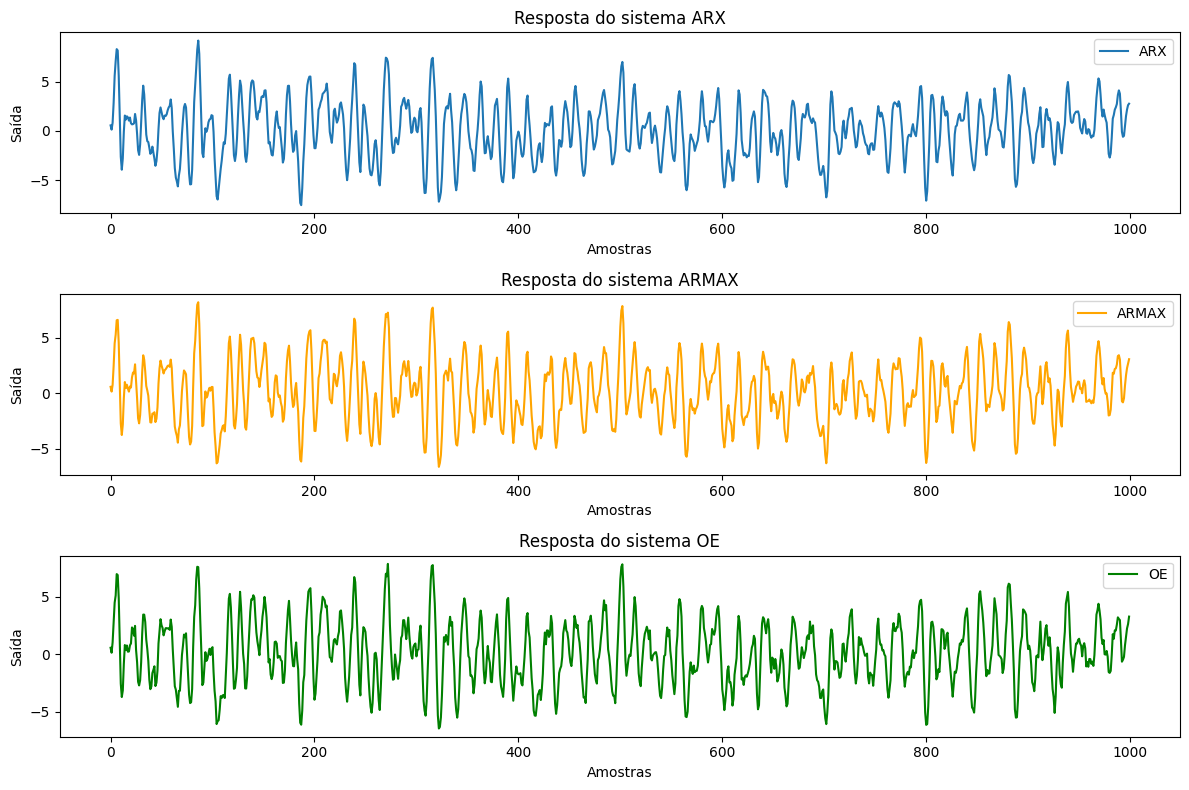

In [48]:
# A(q) = 1 - 1.5q^-1 + 0.7q^-2
# B(q) = 0 + 1.0q^-1 + 0.5q^-2
# C(q) = 1 + 0.8q^-1 + 0.0q^-2

# arx Ay = Bu + e: y[k] - 1.5y[k-1] + 0.7y[k-2] = 1.0u[k-1] + 0.5u[k-2] + e[k]
#                  y[k] = 1.5y[k-1] - 0.7y[k-2] + 1.0u[k-1] + 0.5u[k-2] + e[k]


def arx(y, u, e, k):
    if k < 2:
        return e[k]  # Not enough data for y[k-1], y[k-2], u[k-1], u[k-2]
    return 1.5 * y[k - 1] - 0.7 * y[k - 2] + 1.0 * u[k - 1] + 0.5 * u[k - 2] + e[k]


# armax Ay = Bu + Ce: y[k] - 1.5y[k-1] + 0.7y[k-2] = 1.0u[k-1] + 0.5u[k-2] + e[k] - 0.8e[k-1]
#                     y[k] = 1.5y[k-1] - 0.7y[k-2] + 1.0u[k-1] + 0.5u[k-2] + e[k] - 0.8e[k-1]


def armax(y, u, e, k):
    if k < 2:
        return e[k]  # Not enough data for y[k-1], y[k-2], u[k-1], u[k-2], e[k-1]
    return (
        1.5 * y[k - 1]
        - 0.7 * y[k - 2]
        + 1.0 * u[k - 1]
        + 0.5 * u[k - 2]
        + e[k]
        - 0.8 * e[k - 1]
    )


# F(q) = A(q)

# oe Fy = Bu + Fe: y[k] - 1.5y[k-1] + 0.7y[k-2] = 1.0u[k-1] + 0.5u[k-2] + e[k] - 1.5e[k-1] + 0.7e[k-2]
#                  y[k] = 1.5y[k-1] - 0.7y[k-2] + 1.0u[k-1] + 0.5u[k-2] + e[k] - 1.5e[k-1] + 0.7e[k-2]


def oe(y, u, e, k):
    if k < 2:
        return e[
            k
        ]  # Not enough data for y[k-1], y[k-2], u[k-1], u[k-2], e[k-1], e[k-2]
    return (
        1.5 * y[k - 1]
        - 0.7 * y[k - 2]
        + 1.0 * u[k - 1]
        + 0.5 * u[k - 2]
        + e[k]
        - 1.5 * e[k - 1]
        + 0.7 * e[k - 2]
    )


# Set random seed for reproducibility
np.random.seed(0)
N_fit = 1000
N_val = 500

# nu = white gaussian with zero mean and variance 0.1
nu = np.random.normal(0, np.sqrt(0.1), N_fit)

# u = white uniform in [-1, 1]
u_fit = np.random.uniform(-1, 1, N_fit)
u_val = np.random.uniform(-1, 1, N_val)

# Set initial conditions
y_arx, y_armax, y_oe = np.zeros(N_fit), np.zeros(N_fit), np.zeros(N_fit)

# Simulate the systems
for k in range(N_fit):
    y_arx[k] = arx(y_arx, u_fit, nu, k)
    y_armax[k] = armax(y_armax, u_fit, nu, k)
    y_oe[k] = oe(y_oe, u_fit, nu, k)

# Plot the results
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(y_arx, label="ARX")
plt.title("Resposta do sistema ARX")
plt.xlabel("Amostras")
plt.ylabel("Saída")
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(y_armax, label="ARMAX", color="orange")
plt.title("Resposta do sistema ARMAX")
plt.xlabel("Amostras")
plt.ylabel("Saída")
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(y_oe, label="OE", color="green")
plt.title("Resposta do sistema OE")
plt.xlabel("Amostras")
plt.ylabel("Saída")
plt.legend()

plt.tight_layout()
plt.show()

# Estimação de ARX

Dado

\begin{equation*}
A(z)y[k] = B(z)u[k] + e[k]
\end{equation*}

com dois atrasos em $A(z)$ e $B(z)$,

\begin{align*}
y[k] + a_1y[k-1] + a_2y[k-2] &= b_1u[k-1] + b_2u[k-2] + e[k] \\
y[k] &= -a_1y[k-1] - a_2y[k-2] + b_1u[k-1] + b_2u[k-2] + e[k]
\end{align*}

Seja

\begin{align*}
Y &=
\begin{bmatrix}
y[2] \\
y[3] \\
y[4] \\
\vdots \\
y[N-1]
\end{bmatrix} \\
\Phi &=
\begin{bmatrix}
y[1] & y[0] & u[1] & u[0] \\
y[2] & y[1] & u[2] & u[1] \\
y[3] & y[2] & u[3] & u[2] \\
\vdots & \vdots & \vdots & \vdots \\
y[N-2] & y[N-3] & u[N-2] & u[N-3]
\end{bmatrix} \\
\theta &=
\begin{bmatrix}
-a_1 \\
-a_2 \\
b_1 \\
b_2
\end{bmatrix} \\
E &=
\begin{bmatrix}
e[2] \\
e[3] \\
e[4] \\
\vdots \\
e[N-1]
\end{bmatrix}
\end{align*},

então

\begin{equation*}
Y = \Phi\theta + E
\end{equation*}

e a estimativa por mínimos quadrados é

\begin{equation*}
\hat{\theta} = (\Phi^T\Phi)^{-1}\Phi^TY
\end{equation*}

Coeficientes estimados: A = [ 1.         -1.49415333  0.69915224], B = [0.         0.96999492 0.49875072]


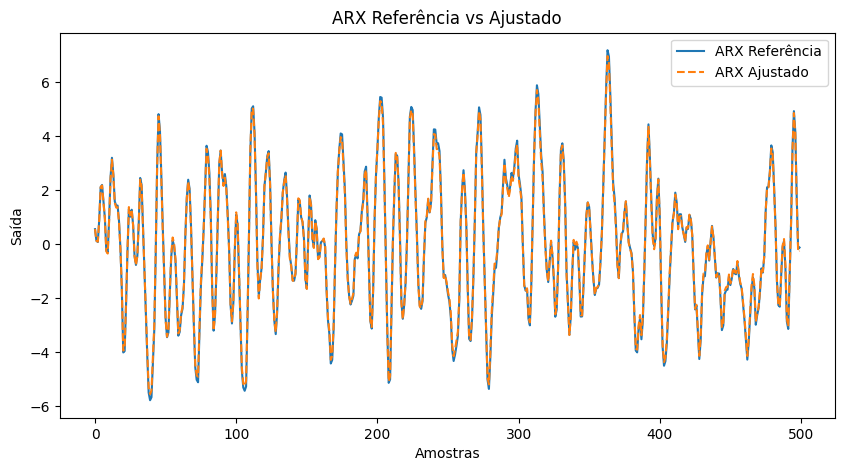

In [49]:
def fit_arx(
    y: np.ndarray, u: np.ndarray, na: int, nb: int
) -> tuple[np.ndarray, np.ndarray]:
    """
    Estimate ARX model parameters using least squares.

    Parameters:
    y : np.ndarray
        Output data.
    u : np.ndarray
        Input data.
    na : int
        Number of poles (order of A).
    nb : int
        Number of zeros (order of B).

    Returns:
    A : np.ndarray
        Estimated coefficients of A polynomial.
    B : np.ndarray
        Estimated coefficients of B polynomial.
    """
    N = len(y)
    assert len(u) == N, "Input and output data must have the same length."

    # Ensure 0 mean for input and output
    u = u - np.mean(u)
    y = y - np.mean(y)

    # Construct the regression matrix
    phi = np.zeros((N - max(na, nb), na + nb))
    for k in range(max(na, nb), N):
        # Fill in the A part (output past values)
        for i in range(1, na + 1):
            phi[k - max(na, nb), i - 1] = -y[k - i]
        # Fill in the B part (input past values)
        for j in range(1, nb + 1):
            phi[k - max(na, nb), na + j - 1] = u[k - j]

    # Corresponding output vector
    y_reg = y[max(na, nb) :]

    # Solve the least squares problem
    theta, _, _, _ = np.linalg.lstsq(phi, y_reg)

    # Separate A and B coefficients
    A = np.concatenate(([1], theta[:na]))  # A[0] = 1
    B = np.concatenate(([0], theta[na:]))  # B[0] = 0

    return A, B


A, B = fit_arx(y_arx, u_fit, na=2, nb=2)
print(f"Coeficientes estimados: A = {A}, B = {B}")


def arx_fitted(y, u, e, k, A, B):
    if k < 2:
        return e[k]  # Not enough data for y[k-1], y[k-2], u[k-1], u[k-2]
    return (
        -A[1] * y[k - 1]
        - A[2] * y[k - 2]
        + B[0] * u[k]
        + B[1] * u[k - 1]
        + B[2] * u[k - 2]
        + e[k]
    )

y_oe_fit, y_oe_ref = np.zeros(N_val), np.zeros(N_val)

for k in range(N_val):
    y_oe_fit[k] = arx_fitted(y_oe_fit, u_val, nu, k, A, B)
    y_oe_ref[k] = arx(y_oe_ref, u_val, nu, k)

plt.figure(figsize=(10, 5))
plt.plot(y_oe_ref, label="ARX Referência")
plt.plot(y_oe_fit, label="ARX Ajustado", linestyle="--")
plt.title("ARX Referência vs Ajustado")
plt.xlabel("Amostras")
plt.ylabel("Saída")
plt.legend()
plt.show()

# Estimação de ARMAX

Dado

\begin{equation*}
A(z)y[k] = B(z)u[k] + C(z)e[k]
\end{equation*}

com dois atrasos em $A(z)$, $B(z)$ e $C(z)$,

\begin{align*}
y[k] + a_1y[k-1] + a_2y[k-2] &= b_1u[k-1] + b_2u[k-2] + e[k] + c_1e[k-1] + c_2e[k-2] \\
y[k] &= -a_1y[k-1] - a_2y[k-2] + b_1u[k-1] + b_2u[k-2] + e[k] + c_1e[k-1] + c_2e[k-2]
\end{align*}

A construção

\begin{equation*}
Y = \Phi\theta
\end{equation*}

com

\begin{align*}
Y &=
\begin{bmatrix}
y[2] \\
y[3] \\
y[4] \\
\vdots \\
y[N-1]
\end{bmatrix} \\
\Phi &=
\begin{bmatrix}
y[1] & y[0] & u[1] & u[0] & e[1] & e[0] \\
y[2] & y[1] & u[2] & u[1] & e[2] & e[1] \\
y[3] & y[2] & u[3] & u[2] & e[3] & e[2] \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
y[N-2] & y[N-3] & u[N-2] & u[N-3] & e[N-2] & e[N-3]
\end{bmatrix} \\
\theta &=
\begin{bmatrix}
-a_1 \\
-a_2 \\
b_1 \\
b_2 \\
c_1 \\
c_2
\end{bmatrix}
\end{align*}

é valida, mas não pode ser usada para estimar $\theta$ por mínimos quadrados, pois $e[k]$ não é conhecido. Neste caso, o método *quadrados mínimos extendido* é uma solução. O algoritmo é:

1. Estime um modelo ARX sobre os dados;
2. Calcule os resíduos do modelo ARX estimado;
3. Use os resíduos como uma estimativa para $e[k]$ e construa a matriz de regressores;
4. Estime o modelo ARMAX usando mínimos quadrados;
5. Calcule os resíduos do modelo ARMAX estimado;
6. Repita os passos 3 a 5 até convergência.

Coeficientes estimados: A = [ 1.         -1.44956014  0.67743718], B = [0.         0.95916641 0.55992147], C = [ 1.         -0.67414811  0.04309484], iterações = 99


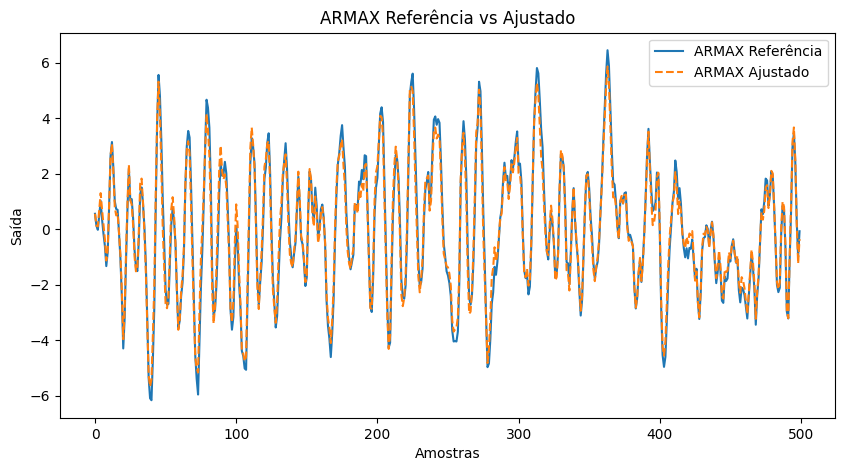

In [55]:
def armax_fitted(y, u, e, k, A, B, C):
    if k < 2:
        return e[
            k
        ]  # Not enough data for y[k-1], y[k-2], u[k-1], u[k-2], e[k-1], e[k-2]
    return (
        -A[1] * y[k - 1]
        - A[2] * y[k - 2]
        + B[0] * u[k]
        + B[1] * u[k - 1]
        + B[2] * u[k - 2]
        + C[0] * e[k]
        + C[1] * e[k - 1]
        + C[2] * e[k - 2]
    )


def fit_armax(
    y: np.ndarray,
    u: np.ndarray,
    na: int,
    nb: int,
    nc: int,
    tol: float | None = None,
    max_iter: int | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, int]:
    """
    Estimate ARMAX parameters using Extended Least Squares (Iterative GLS / IGLS).
    Returns (A, B, C) where A = [1, a1, ..., a_na], B = [0, b1, ..., b_nb], C = [1, c1, ..., c_nc].
    """

    N = len(y)
    assert len(u) == N, "u and y must have same length."

    if max_iter is None:
        max_iter = N // 10

    # Remove means
    u = u - np.mean(u)
    y = y - np.mean(y)

    # quick case: nc == 0 reduces to ARX LS
    if nc == 0:
        A, B = fit_arx(y, u, na, nb)
        C = np.array([1.0])
        return A, B, C, 0

    # Initialization from ARX (c's = 0)
    A, B = fit_arx(y, u, na, nb)
    C = np.concatenate(([1.0], np.zeros(nc)))

    # initial residuals from ARX one-step-ahead
    ehat = np.zeros_like(y)
    for k in range(N):
        yhat_k = armax_fitted(y, u, ehat, k, A, B, C)
        ehat[k] = y[k] - yhat_k

    start = max(na, nb, nc)
    M = N - start
    if M <= 0:
        raise ValueError(
            "Not enough data points for the chosen model orders. Increase N or reduce orders."
        )

    theta_prev = np.concatenate((A[1:], B[1:], C[1:]))

    if tol is None:
        tol = float(0.01 * np.max(np.abs(theta_prev)))

    for it in range(max_iter):
        # Build regression matrix using current innovations (ehat)
        phi = np.zeros((M, na + nb + nc))
        for k in range(start, N):
            r = k - start
            # A part: -y[k-1], ..., -y[k-na]
            for i in range(1, na + 1):
                phi[r, i - 1] = -y[k - i]
            # B part: u[k-1], ..., u[k-nb]
            for j in range(1, nb + 1):
                phi[r, na + j - 1] = u[k - j]
            # C part: ehat[k-1], ..., ehat[k-nc]
            for l in range(1, nc + 1):
                phi[r, na + nb + l - 1] = ehat[k - l]

        y_reg = y[start:]
        theta, *_ = np.linalg.lstsq(phi, y_reg, rcond=None)

        # Unpack into A,B,C (with leading 1/0)
        A_new = np.concatenate(([1.0], theta[:na]))
        B_new = np.concatenate(([0.0], theta[na : na + nb]))
        C_new = np.concatenate(([1.0], theta[na + nb : na + nb + nc]))

        # Compute new residuals using updated parameters
        ehat_new = np.zeros_like(y)
        for k in range(N):
            yhat_k = armax_fitted(y, u, ehat_new, k, A_new, B_new, C_new)
            ehat_new[k] = y[k] - yhat_k

        theta_curr = np.concatenate((A_new[1:], B_new[1:], C_new[1:]))
        diff = np.linalg.norm(theta_curr - theta_prev)

        # update for next iteration
        A, B, C = A_new, B_new, C_new
        ehat = ehat_new
        theta_prev = theta_curr

        if diff < tol:
            break

    return A, B, C, it


# Fit ARMAX by ELS
A, B, C, it = fit_armax(y_armax, u_fit, na=2, nb=2, nc=2)

print(f"Coeficientes estimados: A = {A}, B = {B}, C = {C}, iterações = {it}")

y_arx_fit, y_arx_ref = np.zeros(N_val), np.zeros(N_val)

for k in range(N_val):
    y_arx_fit[k] = armax_fitted(y_arx_fit, u_val, nu, k, A, B, C)
    y_arx_ref[k] = armax(y_arx_ref, u_val, nu, k)

plt.figure(figsize=(10, 5))
plt.plot(y_arx_ref, label="ARMAX Referência")
plt.plot(y_arx_fit, label="ARMAX Ajustado", linestyle="--")
plt.title("ARMAX Referência vs Ajustado")
plt.xlabel("Amostras")
plt.ylabel("Saída")
plt.legend()
plt.show()

# Estimação de OE

Dado

\begin{equation*}
F(z)y[k] = B(z)u[k] + F(z)e[k]
\end{equation*}

com dois atrasos em $F(z)$ e $B(z)$,

\begin{align*}
y[k] + f_1y[k-1] + f_2y[k-2] &= b_0u[k] + b_1u[k-1] + b_2u[k-2] + f_0e[k] + f_1e[k-1] + f_2e[k-2] \\
y[k] &= -f_1y[k-1] - f_2y[k-2] + b_0u[k] + b_1u[k-1] + b_2u[k-2] + f_0e[k] + f_1e[k-1] + f_2e[k-2]
\end{align*}

Assim como para ARMAX, a separação entre saída, regressores e parâmetros constrói um sistema não linear nos parâmetros. Porém, neste caso, não é possível partir de uma estimativa inicial que ignore os erros de medição, já que assumir $F(z) = 1$ desconsidera, também, a dinâmica do sistema. Resta, então, resolver por otimização não linear. Um algoritmo candidato é:

1. Estime F como A em um modelo ARX (chute inicial);
2. Compute B correspondente, dado que y, u e F são conhecidos, assim como e, assumido zero;
3. Calcule os resíduos do modelo OE estimado;
4. Compute um novo F, minimizando os resíduos;
5. Repita os passos 2 a 4 até convergência.

Coeficientes estimados: F = [ 1.         -1.49637142  0.69816569], B = [0.         0.96415248 0.53712348]


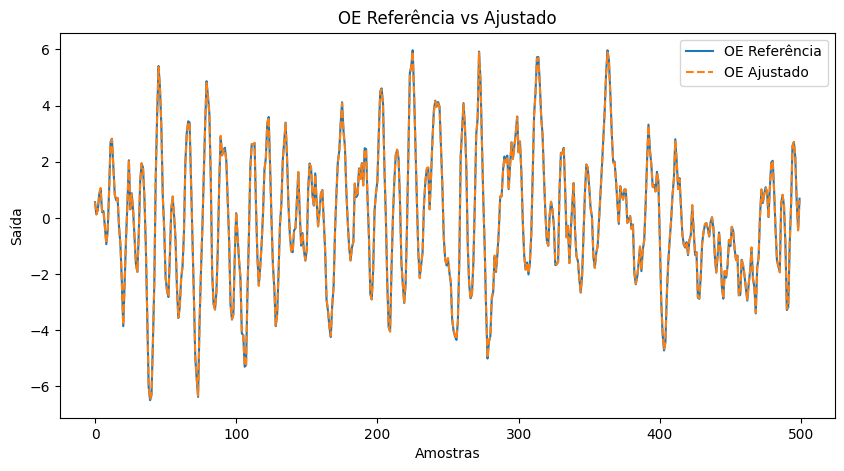

In [54]:
import numpy as np
from scipy.signal import lfilter
from scipy.optimize import least_squares

def build_V(F: np.ndarray, u: np.ndarray, nb: int) -> np.ndarray:
    """
    Build regression matrix V for given denominator coefficients 'a = [1, f...]'
    and input u. Returns V with shape (N, nb) where column j is filtered u delayed
    by j (1..nb).
    """

    N = len(u)
    a = np.concatenate(([1.0], F))
    V = np.zeros((N, nb), dtype=float)
    for j in range(1, nb + 1):
        u_del = np.zeros_like(u, dtype=float)
        if j < N:
            u_del[j:] = u[: N - j]
        # filter with denominator a (numerator is 1)
        vj = lfilter([1.0], a, u_del)
        V[:, j - 1] = vj
    return V


def fit_B(F: np.ndarray, y: np.ndarray, u: np.ndarray, nb: int, start: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Given denominator coefficients 'F' (without leading 1), solve least squares
    for B (length nb). Returns (B_hat, V_reg) where V_reg = V[start:, :].
    """

    V = build_V(F, u, nb)
    V_reg = V[start:, :]
    y_reg = y[start:]
    B_hat = np.linalg.lstsq(V_reg, y_reg)[0].ravel()
    return B_hat, V_reg


def fit_oe(y: np.ndarray, u: np.ndarray, nf: int, nb: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Output-Error (OE) estimation:
      - returns F_full (shape nf+1) with leading 1: [1, f1, f2, ...]
      - returns B_full (shape nb+1) with leading 0: [0, b1, b2, ...]
    """
    
    N = len(y)
    if len(u) != N:
        raise AssertionError("u and y must have same length")

    # zero-mean signals
    y = y - np.mean(y)
    u = u - np.mean(u)

    start = max(nf, nb)
    if N - start <= (nf + nb):
        raise ValueError("Not enough data for chosen orders. Increase N or reduce orders.")

    # Get ARX initial estimate
    F_init_full, _ = fit_arx(y, u, nf, nb)

    # Remove leading 1 to obtain initial guesses for optimization variables
    F_init = F_init_full[1:]

    def residuals(F_var):
        B_hat, V_reg = fit_B(F_var, y, u, nb, start)
        r = y[start:] - V_reg.dot(B_hat)
        return r

    # Solve for F coefficients (excluding leading 1)
    res = least_squares(residuals, F_init)
    F_opt = res.x.ravel()

    # Given optimized F, estimate B by linear LS
    B_hat, _ = fit_B(F_opt, y, u, nb, start)

    # Return full polynomials
    F_full = np.concatenate(([1.0], F_opt))
    B_full = np.concatenate(([0.0], B_hat))

    return F_full, B_full

F, B = fit_oe(y_oe, u_fit, nf=2, nb=2)

print(f"Coeficientes estimados: F = {F}, B = {B}")

def oe_fitted(y, u, e, k, F, B):
    if k < 2:
        return e[
            k
        ]  # Not enough data for y[k-1], y[k-2], u[k-1], u[k-2], e[k-1], e[k-2]
    return (
        -F[1] * y[k - 1]
        - F[2] * y[k - 2]
        + B[0] * u[k]
        + B[1] * u[k - 1]
        + B[2] * u[k - 2]
        + F[0] * e[k]
        + F[1] * e[k - 1]
        + F[2] * e[k - 2]
    )


y_oe_fit, y_oe_ref = np.zeros(N_val), np.zeros(N_val)

for k in range(N_val):
    y_oe_fit[k] = oe_fitted(y_oe_fit, u_val, nu, k, F, B)
    y_oe_ref[k] = oe(y_oe_ref, u_val, nu, k)

plt.figure(figsize=(10, 5))
plt.plot(y_oe_ref, label="OE Referência")
plt.plot(y_oe_fit, label="OE Ajustado", linestyle="--")
plt.title("OE Referência vs Ajustado")
plt.xlabel("Amostras")
plt.ylabel("Saída")
plt.legend()
plt.show()

# Comparação

## ARX

A identificação foi simples e resultou em um modelo com boa performance na validação. Isso decorre de ser um modelo totalmente linear nos parametros desde o princípio, o que permite o uso direto de mínimos quadrados.

## ARMAX

A identificação ainda é consideravelmente simples, dado que estimar os erros é um problema de regressão linear. Assim como o ruído filtrado é a diferença entre a saída medida e a resposta da função geradora, os resíduos são a diferença entre a saída medida e a resposta do modelo estimado. Por isso, este é um estimador adequado para aquele. A performance decorrente dessa consideração, no entanto, foi inferior à dos demais casos.

## OE

Descartada a possibilidade de regressão linear, a identificação é mais complexa. Tal complexidade, entretanto, é concentrada na seleção de um novo candidato para F, passo que pode ser delegado ao módulo SciPy. Com esta ferramenta mais robusta, a performance do modelo foi, visualmente, tão boa quanto a do ARX.
